In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import math
import pyaudio


In [2]:
a = np.linspace(0,1,5)
b = np.sin(a)
print(a)
print(b)


[0.   0.25 0.5  0.75 1.  ]
[0.         0.24740396 0.47942554 0.68163876 0.84147098]


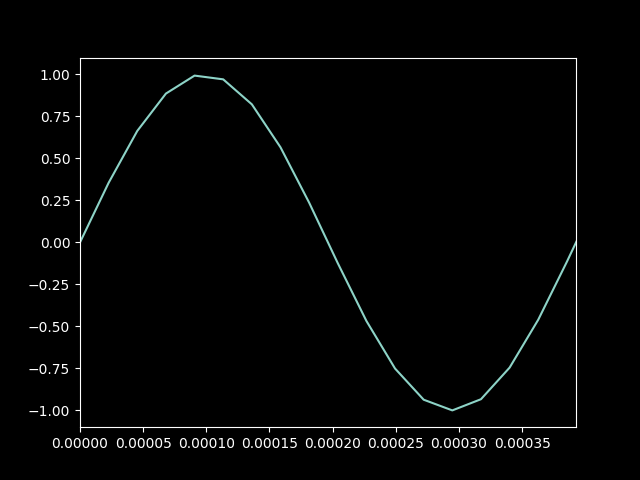

In [3]:
RATE = 44100
DURATION = 5
FREQUENCY = 16000

xf = np.linspace(0, DURATION, RATE * DURATION)
yf = np.sin(FREQUENCY * xf)

fig, ax = plt.subplots()

ax.plot(xf, yf)
ax.set_xlim(0, 2 * math.pi / FREQUENCY)
plt.show()


In [4]:
p = pyaudio.PyAudio()

stream = p.open(rate=44100, channels=1, format=pyaudio.paFloat32,output=True)

data = yf.astype(np.float32).tobytes()
stream.write(data)


In [5]:
RATE = 44100
DURATION = 5
FREQUENCY = 2000


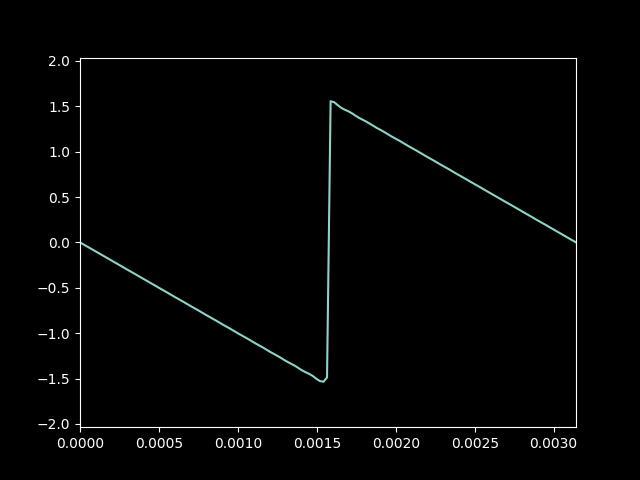

In [6]:
xf = np.linspace(0, DURATION, RATE * DURATION)
yf = sum(
    (-1) ** n / n * np.sin(n * FREQUENCY * xf)
    for n in range(1, 1001)
)

fig, ax = plt.subplots()

ax.plot(xf, yf)
ax.set_xlim(0, 2 * math.pi / FREQUENCY)
plt.show()


In [7]:
p = pyaudio.PyAudio()

stream = p.open(rate=44100, channels=1, format=pyaudio.paFloat32,output=True)

data = yf.astype(np.float32).tobytes()
stream.write(data)

In [8]:
RATE = 44100
DURATION = 2
FREQUENCY = 2000

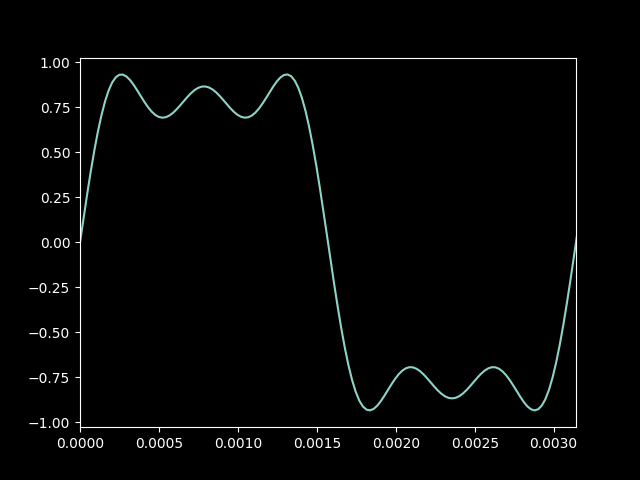

In [9]:
xf = np.linspace(0, DURATION, RATE * DURATION)
yf = sum(
    1 / n * np.sin(n * FREQUENCY * xf)
    for n in range(1, 7, 2)
)

fig, ax = plt.subplots()

ax.plot(xf, yf)
ax.set_xlim(0, 2 * math.pi / FREQUENCY)
plt.show()


In [10]:
p = pyaudio.PyAudio()

stream = p.open(rate=44100, channels=1, format=pyaudio.paFloat32,output=True)

data = yf.astype(np.float32).tobytes()
stream.write(data)

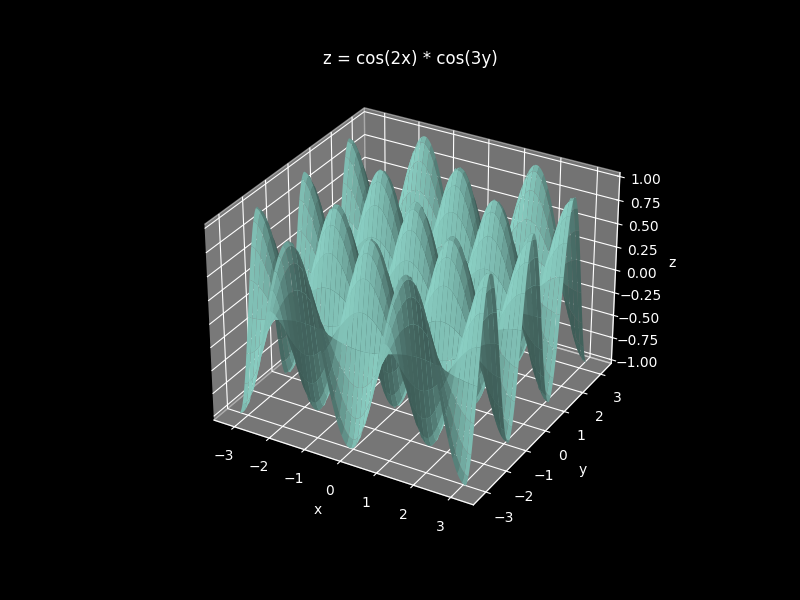

In [11]:

# Parameters
m = 2
n = 3

# Create grid
x = np.linspace(-np.pi, np.pi, 300)
y = np.linspace(-np.pi, np.pi, 300)
X, Y = np.meshgrid(x, y)

# Function
Z = np.cos(m * X) * np.cos(n * Y)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, edgecolor='none')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f"z = cos({m}x) * cos({n}y)")

plt.show()


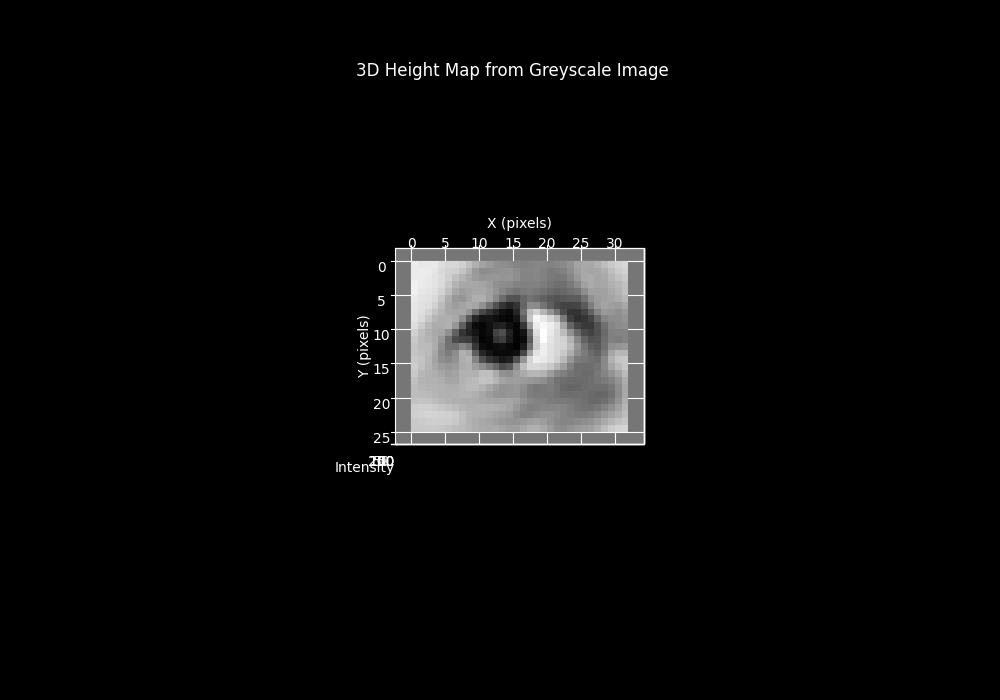

In [12]:
from PIL import Image

# ---- Load Image ----
# Replace 'image.bmp' with your file
img = Image.open("albert-eye.bmp").convert("L")   # convert to greyscale
Z = np.array(img)

# Image dimensions
h, w = Z.shape

# ---- Create Meshgrid ----
# x runs left→right, y runs top→bottom
x = np.arange(0, w)
y = np.arange(0, h)
X, Y = np.meshgrid(x, y)

# ---- Plot ----
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X, Y, Z,
    cmap="gray",
    edgecolor="none",
    rstride=1,
    cstride=1,
    antialiased=True
)

ax.set_title("3D Height Map from Greyscale Image")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
ax.set_zlabel("Intensity")
ax.invert_yaxis()
ax.set_proj_type('ortho')

z_scale = (Z.max() - Z.min()) if np.ptp(Z) > 0 else 1.0
ax.set_box_aspect((w, h, 0.25 * z_scale))  # (X, Y, Z) relative scales

ax.view_init(elev=90, azim=270)

plt.show()